## ICA review example

NBL013: this one has TWO ECG-correlated components. That's okay! Exclude them both.

#### When you're reviewing ICs, remember, it's better to include some artifact than reject real neural data!!

In [1]:
# load packages
import numpy as np
import os
import time
import mne
from mne.io import read_raw_fif
from mne.preprocessing import ICA, read_ica
%matplotlib inline

In [2]:
# filter params
filt_l, filt_h = 1, 200
filt_notch = 60

# ICA params
decim = 5
reject = dict(mag=5e-12, grad=4e-10)
random_state = 42
max_iter = 10000

In [3]:
# subject info
subject = 'nbl_013'
session = '01'

# file paths
meg_dir = os.path.join('/mnt/sphere/nbl/processed_meg/', subject, 'ses-'+session)
raw_fname = os.path.join(meg_dir, f"{subject}_ALL_sss_raw.fif")
er_fname = os.path.join(meg_dir, f"{subject}_emptyroom_sss_raw.fif")
bads_list_fname = os.path.join(meg_dir, f"{subject}_bads.txt")
ica_solution_fname = os.path.join(meg_dir, f"{subject}_ALL-ica.fif")
ica_processed_fname = os.path.join(meg_dir, f"{subject}_ALL_post_ica-raw.fif")  # ICA applied to raw data

if not os.path.exists(bads_list_fname):
    raise FileNotFoundError(f"Bad channels file not found: {bads_list_fname}. Go back and make it.")
with open(bads_list_fname, 'r') as f: bads = [line.strip() for line in f.readlines()]

In [4]:
## load in raw data, remove bad channels, and load in ICA solution
print(f"Reading raw file for {subject}...")
t = time.time()
raw = read_raw_fif(raw_fname, preload=True, verbose=True)
elapsed_readraw = time.time() - t
print(f"Loaded in {elapsed_readraw:.1f} seconds.\n")

print("Excluding bad channels...")
raw.info['bads'] = bads
print('Bad channels:', bads)
raw.pick(picks='all', exclude='bads')
raw.info.normalize_proj()

print("\nFiltering data...")
raw = raw.filter(filt_l, filt_h, picks='meg', n_jobs=-1)
raw = raw.notch_filter(filt_notch, picks='meg', n_jobs=-1)

Reading raw file for nbl_013...
Opening raw data file /mnt/sphere/nbl/processed_meg/nbl_013/ses-01/nbl_013_ALL_sss_raw.fif...
    Range : 35000 ... 1695999 =     35.000 ...  1695.999 secs
Ready.
Opening raw data file /mnt/sphere/nbl/processed_meg/nbl_013/ses-01/nbl_013_ALL_sss_raw-1.fif...
    Range : 1696000 ... 3356999 =   1696.000 ...  3356.999 secs
Ready.
Opening raw data file /mnt/sphere/nbl/processed_meg/nbl_013/ses-01/nbl_013_ALL_sss_raw-2.fif...
    Range : 3357000 ... 5017999 =   3357.000 ...  5017.999 secs
Ready.
Opening raw data file /mnt/sphere/nbl/processed_meg/nbl_013/ses-01/nbl_013_ALL_sss_raw-3.fif...
    Range : 5018000 ... 5193999 =   5018.000 ...  5193.999 secs
Ready.
Reading 0 ... 5158999  =      0.000 ...  5158.999 secs...
Loaded in 53.6 seconds.

Excluding bad channels...
Bad channels: ['MEG1132', 'MEG1543', 'MEG1843']

Filtering data...
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 1 - 2e+02 Hz

FIR filter parameters
---------------

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 128 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    9.3s
[Parallel(n_jobs=-1)]: Done 237 out of 303 | elapsed:   13.2s remaining:    3.7s
[Parallel(n_jobs=-1)]: Done 298 out of 303 | elapsed:   15.2s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done 303 out of 303 | elapsed:   15.4s finished


Filtering raw data in 3 contiguous segments
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 128 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    6.9s
[Parallel(n_jobs=-1)]: Done 237 out of 303 | elapsed:   11.0s remaining:    3.1s
[Parallel(n_jobs=-1)]: Done 298 out of 303 | elapsed:   14.1s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done 303 out of 303 | elapsed:   14.3s finished


Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 128 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done 237 out of 303 | elapsed:    5.6s remaining:    1.6s
[Parallel(n_jobs=-1)]: Done 298 out of 303 | elapsed:    6.5s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 303 out of 303 | elapsed:    6.6s finished


Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 128 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 160 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done 237 out of 303 | elapsed:    5.8s remaining:    1.6s
[Parallel(n_jobs=-1)]: Done 298 out of 303 | elapsed:    6.9s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 303 out of 303 | elapsed:    7.0s finished


In [5]:
print ("\nReading ICA solution...")
ica = read_ica(ica_solution_fname)


Reading ICA solution...
Reading /mnt/sphere/nbl/processed_meg/nbl_013/ses-01/nbl_013_ALL-ica.fif ...
Now restoring ICA solution ...
Ready.


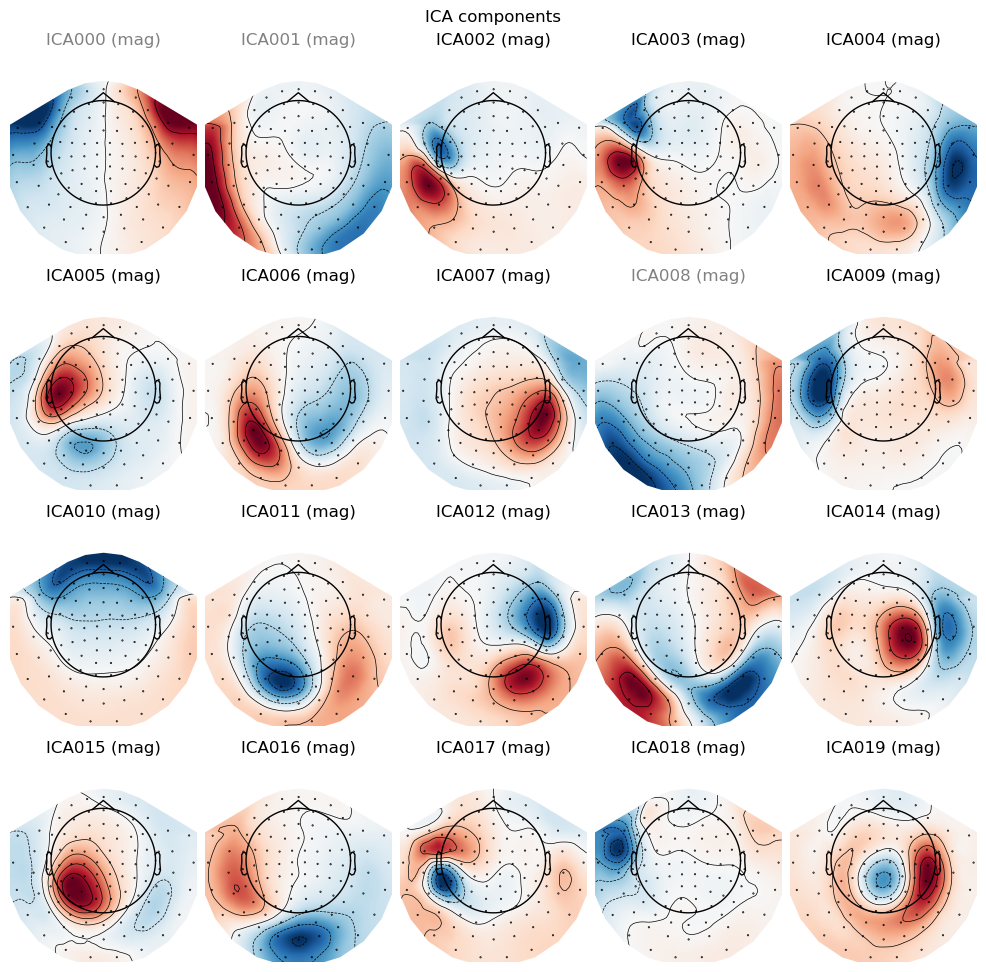

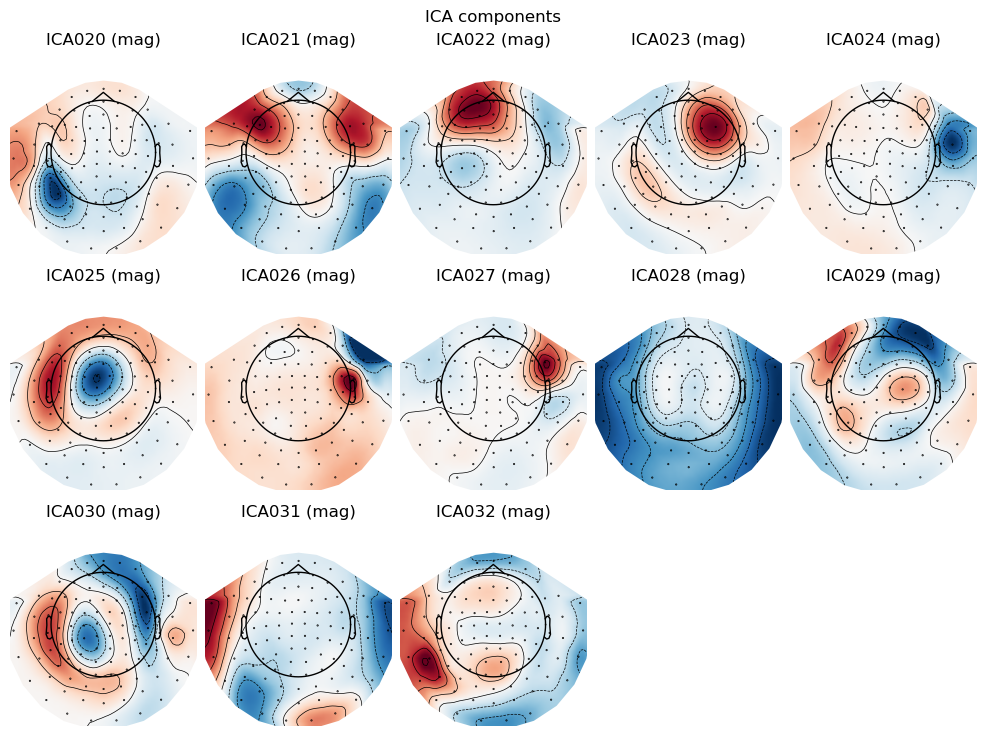

In [6]:
# plot components of the ICA
ica.plot_components();

In [7]:
# EOG and ECG adjustments
print("Finding EOG scores...")
eog_indices, eog_scores = ica.find_bads_eog(raw, ch_name='EOG001', measure='correlation', threshold=0.5)
print("Finding ECG scores...")
ecg_indices, ecg_scores = ica.find_bads_ecg(raw, ch_name='ECG002', measure='correlation', threshold=0.5)

Finding EOG scores...
Using EOG channel: EOG001
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 10000 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cuto

In [8]:
print('Identified EOG comps:', eog_indices)
print('Identified ECG comps:', ecg_indices)
ica.exclude = eog_indices + ecg_indices

Identified EOG comps: [np.int64(0)]
Identified ECG comps: [np.int64(1), np.int64(8)]


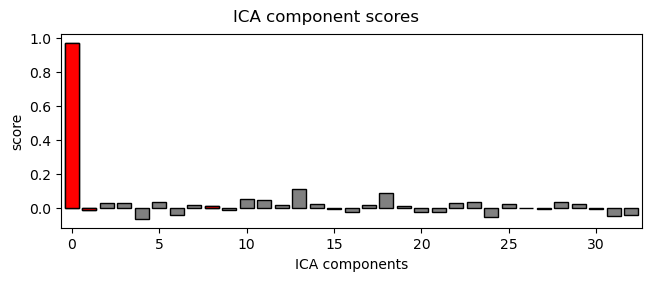

In [9]:
# EOG checks: barplot of ICA component "EOG match" scores
ica.plot_scores(eog_scores);

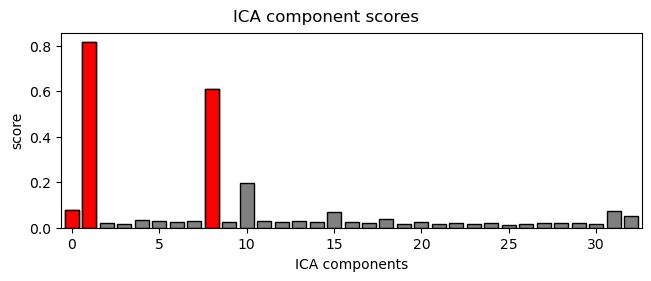

In [10]:
# ECG checks: barplot of ICA component "ECG match" scores
ica.plot_scores(ecg_scores);

Applying ICA to Raw instance
    Transforming to ICA space (33 components)
    Zeroing out 1 ICA component
    Projecting back using 303 PCA components


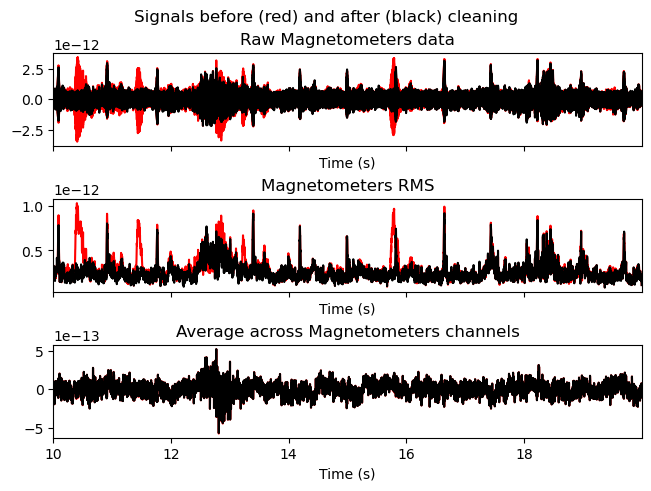

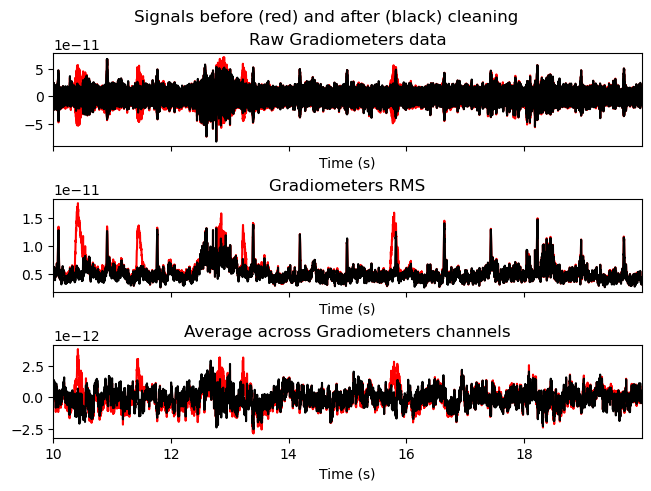

In [11]:
# blinks
ica.exclude = []
eog_indices = [0]
ica.plot_overlay(raw, exclude=eog_indices, picks="meg", start=10.0, stop=20.0);

Applying ICA to Raw instance
    Transforming to ICA space (33 components)
    Zeroing out 2 ICA components
    Projecting back using 303 PCA components


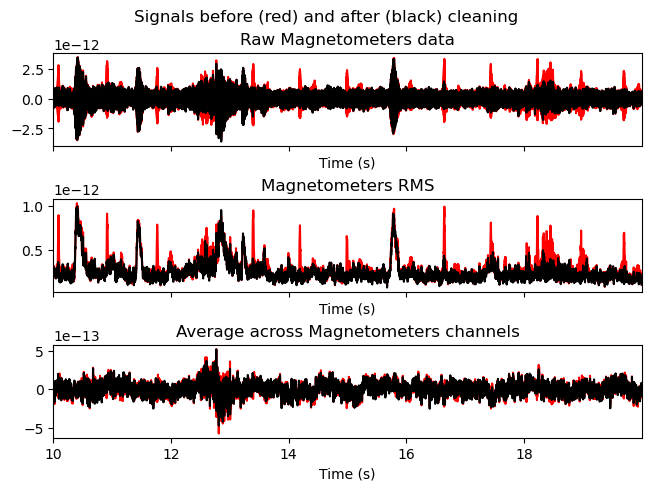

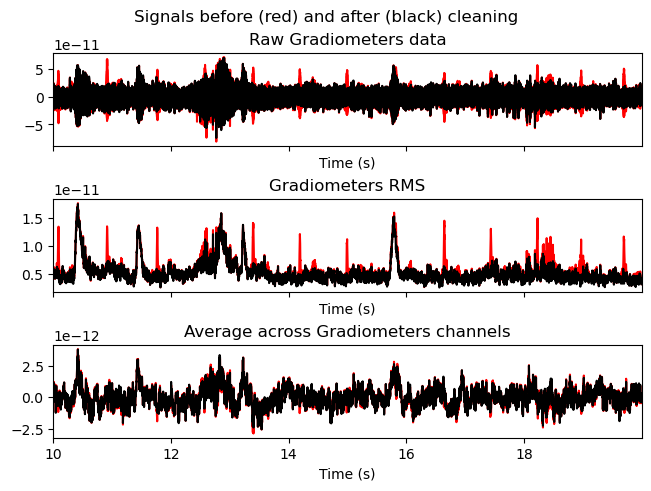

In [12]:
# heartbeats
ecg_indices = [1,8]
ica.plot_overlay(raw, exclude=ecg_indices, picks="meg", start=10.0, stop=20.0);

In [13]:
ica.exclude = eog_indices + ecg_indices

Applying ICA to Raw instance
    Transforming to ICA space (33 components)
    Zeroing out 3 ICA components
    Projecting back using 303 PCA components


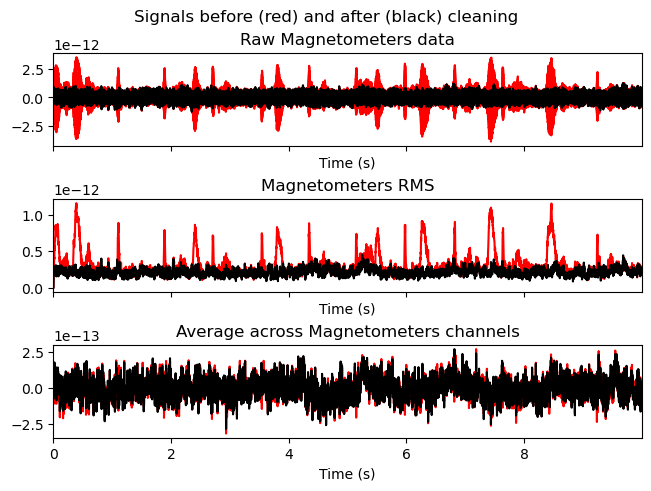

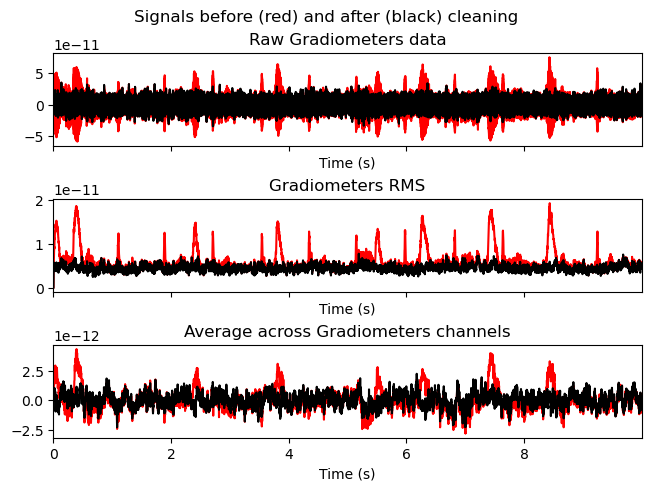

In [14]:
# final results with exclusions
ica.plot_overlay(raw, picks="meg", start=0.0, stop=10.0);

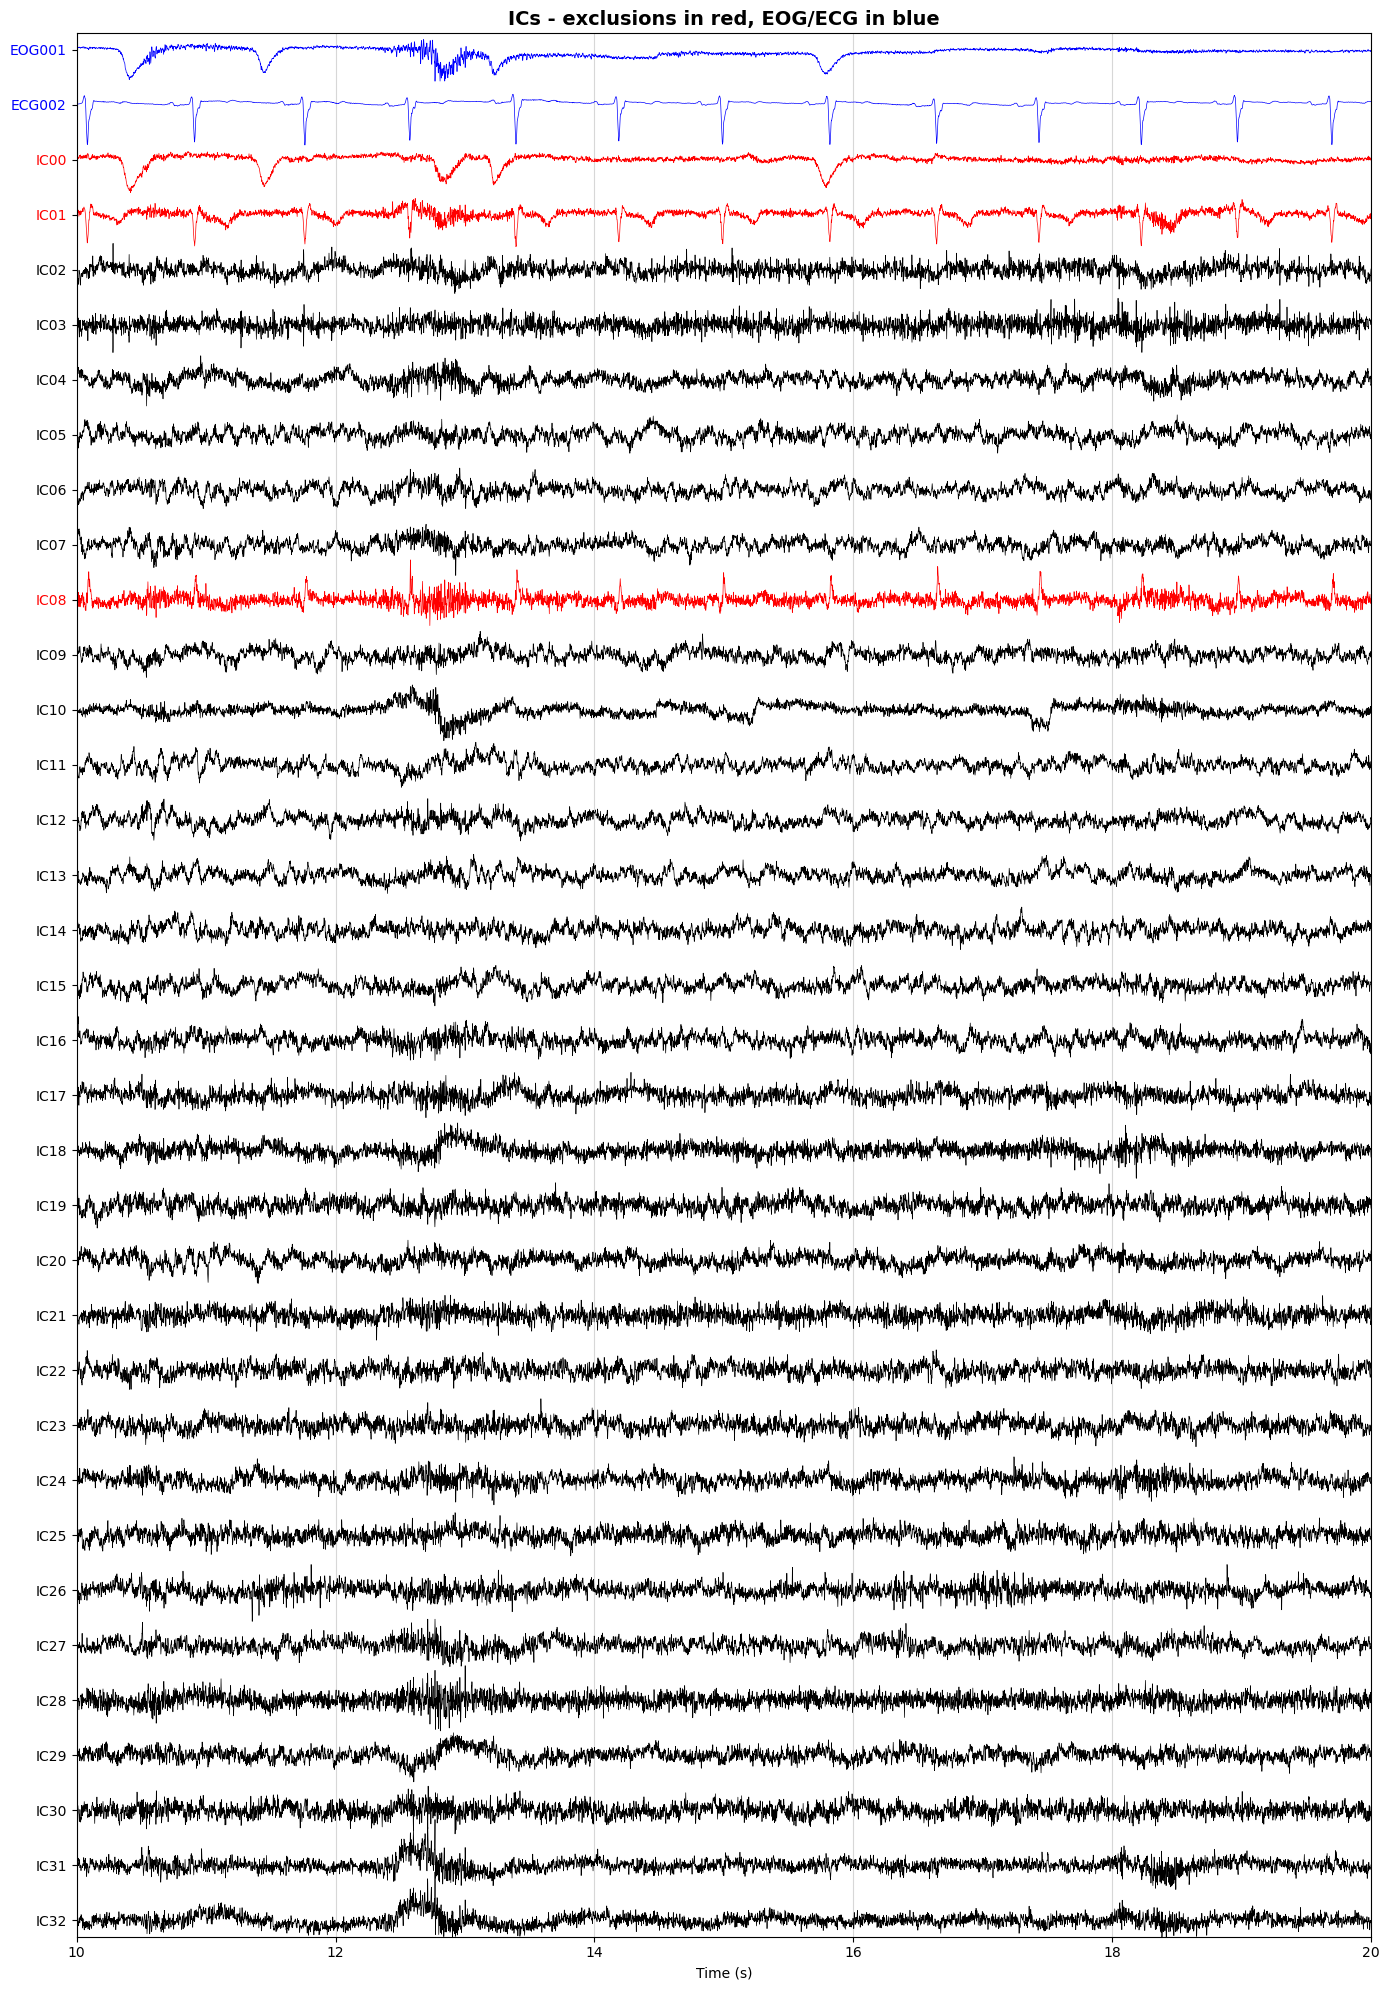

In [15]:
# plot ICs with exclusions in red
import matplotlib.pyplot as plt

sources = ica.get_sources(raw)
start_s = 10  # seconds
duration = 10  # seconds
sfreq = raw.info['sfreq']
start_sample = int(start_s * sfreq)
n_samples = int(duration * sfreq)

ica_data = sources.get_data()[:, start_sample:start_sample+n_samples]
times = sources.times[start_sample:start_sample+n_samples]

# get EOG and ECG channels
eog_channels = [ch for ch in raw.ch_names if 'EOG' in ch.upper()]
ecg_channels = [ch for ch in raw.ch_names if 'ECG' in ch.upper()]
aux_channels = eog_channels + ecg_channels
aux_data = []
aux_labels = []
for ch in aux_channels:
    ch_data = raw.copy().pick(ch).get_data()[:, start_sample:start_sample+n_samples][0]
    aux_data.append(ch_data)
    aux_labels.append(ch)
aux_data = np.array(aux_data)

# combine all channels
n_ics, n_aux = ica_data.shape[0], aux_data.shape[0]
all_data = []
all_labels = []
all_data.append(aux_data)
all_labels.extend(aux_labels)
all_data.append(ica_data)
all_labels.extend([f'IC{i:02d}' for i in range(n_ics)])

all_data = np.vstack(all_data)
data_norm = all_data / np.std(all_data, axis=1, keepdims=True)
offsets = np.arange(n_aux + n_ics)[:, np.newaxis] * 10
data_plot = data_norm + offsets

fig, ax = plt.subplots(figsize=(14, 20))
for idx in range(n_aux):
    ax.plot(times, data_plot[idx], color='blue', linewidth=0.5)
for idx in range(n_ics):
    plot_idx = n_aux + idx
    color = 'red' if idx in ica.exclude else 'black'
    ax.plot(times, data_plot[plot_idx], color=color, linewidth=0.5)
ax.set_yticks(offsets[:, 0])
ax.set_yticklabels(all_labels)

for idx, label in enumerate(ax.get_yticklabels()):
    if idx < n_aux:
        label.set_color('blue')
    elif (idx - n_aux) in ica.exclude:
        label.set_color('red')

ax.set_xlim([start_s, start_s+duration])
ax.set_ylim([offsets[-1, 0] + 3, offsets[0, 0] - 3])
ax.set_xlabel('Time (s)')
ax.set_title('ICs - exclusions in red, EOG/ECG in blue', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.5, axis='x')
plt.tight_layout()
plt.show()